# EDA financiero y features mensuales

## tl;dr

Los flujos están extremadamente concentrados: el 1 % de sociedades concentra aproximadamente el 78,8 % del volumen bruto observado. El análisis evita sumar monedas y usa tres señales de flujo de alta trazabilidad; no interpreta cobros como ingresos ni pagos como gastos.

## Context & Methods

### Key Assumptions

- Solo movimientos `booked` enlazados a un producto bancario con moneda.
- Categorías de financiación, inversión y transferencias no son flujo operativo.
- Las vistas son agregadas; no se incrustan millones de puntos.

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
import pyarrow as pa

ROOT = next(path for path in (Path.cwd(), Path.cwd().parent) if (path / "artifacts").is_dir())
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"blue": "#3568D4", "gold": "#C8942F", "orange": "#D96C2F", "charcoal": "#262B33"}

## Data

Features en grano sociedad/mes/moneda, con meses ausentes explícitos.

In [2]:
features = pl.read_parquet(ROOT / "data/processed/monthly_features.parquet")
scores = pl.read_parquet(ROOT / "artifacts/score/scores.parquet")
features.shape, scores.shape

((26261, 24), (26261, 45))

## Results

### Concentración del volumen bruto

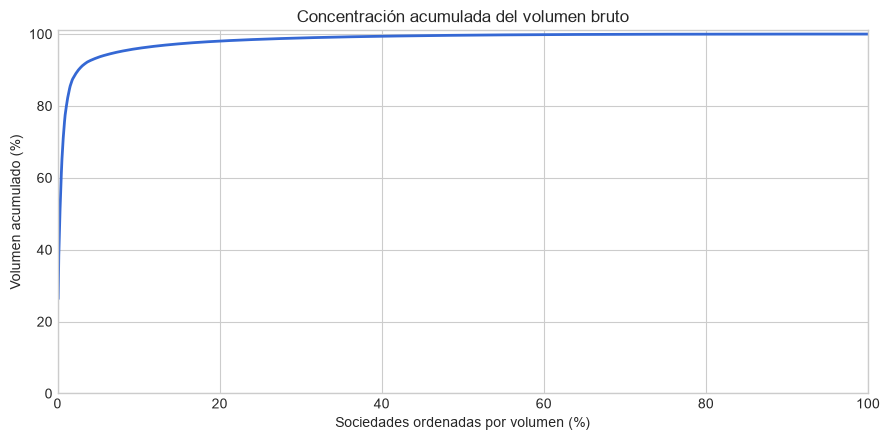

In [3]:
company_volume = (features.filter(pl.col("is_observed") == 1).group_by("company_id").agg(pl.col("gross_flow").sum().alias("gross_flow")).sort("gross_flow", descending=True).with_row_index("rank"))
company_volume = company_volume.with_columns(((pl.col("gross_flow").cum_sum() / pl.col("gross_flow").sum()) * 100).alias("cumulative_share"))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot((company_volume["rank"] + 1).to_numpy() / company_volume.height * 100, company_volume["cumulative_share"].to_numpy(), color=COLORS["blue"], linewidth=2)
ax.set(title="Concentración acumulada del volumen bruto", xlabel="Sociedades ordenadas por volumen (%)", ylabel="Volumen acumulado (%)", xlim=(0, 100), ylim=(0, 101))
plt.tight_layout()
plt.show()

### Casos reales de trayectoria del baseline

In [4]:
latest = scores.filter(pl.col("score_delta_3m").is_not_null()).sort("company_id", "currency", "month").group_by(["company_id", "currency"], maintain_order=True).tail(1)
stable = latest.filter(pl.col("online_regime") == "stable")
selected = pl.concat([latest.sort("score_delta_3m", "company_id", "currency", descending=[True, False, False]).head(1), latest.sort("score_delta_3m", "company_id", "currency").head(1), stable.sort("score", "company_id", "currency", descending=[True, False, False]).head(1), stable.sort("score", "company_id", "currency").head(1)]).unique(subset=["company_id", "currency"], maintain_order=True)
fig = go.Figure()
for row in selected.iter_rows(named=True):
    case = scores.filter((pl.col("company_id") == row["company_id"]) & (pl.col("currency") == row["currency"]) & pl.col("score").is_not_null()).sort("month")
    fig.add_trace(go.Scatter(x=case["month"].to_list(), y=case["score"].to_list(), mode="lines+markers", name=f"{row['company_id']} · {row['currency']}"))
fig.update_layout(title="Nivel y trayectoria: cuatro escalas y regímenes", xaxis_title="Mes", yaxis_title="Score provisional (0–100)", template="plotly_white", height=480)
fig.show()
selected.select("company_id", "currency", "month", "score", "score_delta_3m", "online_regime", "coverage_ratio")

company_id,currency,month,score,score_delta_3m,online_regime,coverage_ratio
str,str,date,f64,f64,str,f64
"""COMP_0809""","""EUR""",2026-07-01,94.793079,90.52107,"""persistent_improvement""",1.0
"""COMP_0641""","""USD""",2026-08-01,1.237299,-82.121156,"""persistent_deterioration""",1.0
"""COMP_0535""","""EUR""",2025-06-01,97.725425,-0.2771,"""stable""",1.0
"""COMP_1067""","""GBP""",2026-08-01,0.309015,-70.424154,"""stable""",1.0


## Takeaways

1. Las comparaciones deben usar transformaciones robustas; medias de importe crudas quedan dominadas por muy pocas sociedades.
2. Nivel y trayectoria se muestran por separado: una sociedad puede conservar buen nivel y deteriorarse.
3. Los casos extremos son candidatos de revisión, no eventos de default ni verdad supervisada.